# Notebook 2 — Balanced-Growth State (Phase 1)

When the economy transitions to state $b$ at date $\tau$, all uncertainty resolves and every variable grows at rate $g_b$ (Assumption 2). This notebook:

1. Solves the **5-equation deterministic equilibrium** in state $b$ for each possible switch date $\tau$
2. Plots how the balanced-state allocations change with $\tau$
3. Verifies market-clearing and sign conditions

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Documents/GitHub/Open_HKT`


Plots.GRBackend()

In [2]:
p = ModelParams()
validate_params(p)
paths = generate_exogenous_paths(p)
println("Parameters validated, exogenous paths generated.")

Parameters validated, exogenous paths generated.


## 1. The Balanced-State System

In the absorbing state $b$, all growth rates equal $g_b$. Normalising by $e_{US,\tau}$, we define hatted (time-invariant) variables:

$$\hat{A} = \beta, \quad \hat{A}^* = \frac{\beta+\chi}{1+\chi}\varepsilon, \quad \hat{D}_{US} = d, \quad \hat{D}_W = d_W\varepsilon$$

where $d = D_{US,\tau}/e_{US,\tau}$, $d_W = D_{W,\tau}/e_{W,\tau}$, $\varepsilon = e_{W,\tau}/e_{US,\tau}$.

**5 unknowns**: $(\omega_b,\ \omega^*_b,\ \theta_b,\ \theta^*_{US,b},\ R_{f,b})$.

**5 equations**:
1. US $\omega$ FOC: $\beta(1-\theta_b)\frac{1}{R_A}(R_{US}-R_W) = \kappa(\omega_b - \bar\omega)$
2. US $\theta$ FOC: $\beta\frac{1}{R_A}(R_f - R_p) = \eta\Upsilon'(\theta_b)$
3. RoW $\omega^*$ FOC: $\beta(1-\theta^*_{US,b})\frac{1}{R^*_A}(R_{US}-R_W) = \kappa(\omega^*_b - \bar\omega^*)$
4. RoW US-bond FOC: $\beta\frac{1}{R^*_A}(R_f - R^*_p) + \chi/\theta^*_{US,b} = 0$
5. Bond clearing: $\theta_b \hat{A} + \theta^*_{US,b} \hat{A}^* = 0$

In [3]:
# ── Solve balanced states for each switch date τ = 1, ..., T+1 ──
T_total = paths.T   # T_max + 1
balanced_states = Vector{BalancedStateResult}(undef, T_total)

x0_bs = nothing
n_fail = 0

for t in 1:T_total
    d   = paths.D_US[t] / paths.e_US[t]
    d_W = paths.D_W[t]  / paths.e_W[t]
    ε   = paths.e_W[t]  / paths.e_US[t]

    balanced_states[t] = solve_balanced_state(p, d, d_W, ε; x0=x0_bs)

    if !balanced_states[t].converged
        n_fail += 1
        @warn "Did not converge at τ=$t"
    end

    bs = balanced_states[t]
    x0_bs = [bs.ω_b, bs.ω_star_b, bs.θ_b, bs.θ_US_star_b, bs.R_f_b]
end

println("Balanced states solved: $(T_total - n_fail)/$(T_total) converged.")

Balanced states solved: 121/121 converged.


In [4]:
# ── Display a few representative solutions ──
println("\n══ Sample Balanced-State Solutions ══")
for t in [1, 10, 20, 40, 60, 80]
    t > T_total && continue
    bs = balanced_states[t]
    @printf("τ=%3d: ω_b=%.4f  ω*_b=%.4f  θ_b=%.6f  θ*_US=%.6f  R_f=%.4f  Q̂_US=%.4f  Q̂_W=%.4f  ‖F‖=%.1e\n",
            t, bs.ω_b, bs.ω_star_b, bs.θ_b, bs.θ_US_star_b, bs.R_f_b,
            bs.Q_US_hat, bs.Q_W_hat, bs.residual_norm)
end


══ Sample Balanced-State Solutions ══
τ=  1: ω_b=0.2629  ω*_b=0.1870  θ_b=-2.855610  θ*_US=0.924930  R_f=1.0642  Q̂_US=0.5286  Q̂_W=1.5151  ‖F‖=6.0e-16
τ= 10: ω_b=0.3205  ω*_b=0.3505  θ_b=-1.845267  θ*_US=1.796070  R_f=1.0745  Q̂_US=0.3125  Q̂_W=0.7011  ‖F‖=8.1e-13
τ= 20: ω_b=0.4863  ω*_b=0.6530  θ_b=-1.188446  θ*_US=3.928189  R_f=1.0637  Q̂_US=0.2429  Q̂_W=0.4084  ‖F‖=8.7e-17
τ= 40: ω_b=0.7442  ω*_b=1.0984  θ_b=-0.703818  θ*_US=26.826913  R_f=1.0523  Q̂_US=0.2619  Q̂_W=0.2513  ‖F‖=1.6e-15
τ= 60: ω_b=0.7951  ω*_b=1.0739  θ_b=-0.626092  θ*_US=275.198587  R_f=1.0512  Q̂_US=0.3115  Q̂_W=0.1896  ‖F‖=3.4e-13
τ= 80: ω_b=0.7996  ω*_b=0.9311  θ_b=-0.618708  θ*_US=3136.110559  R_f=1.0510  Q̂_US=0.3592  Q̂_W=0.1409  ‖F‖=3.5e-13


## 2. How Balanced-State Variables Change with Switch Date $\tau$

As $\tau$ increases, the US dividend-to-endowment ratio $d_\tau = D_{US,\tau}/e_{US,\tau}$ shrinks (because $g_{D,u} < g_{e,u}$), and the relative country size $\varepsilon_\tau = e_W/e_{US}$ also shrinks (because $g_{e,u} > g_{e,W}$). Both affect the balanced-state equilibrium.

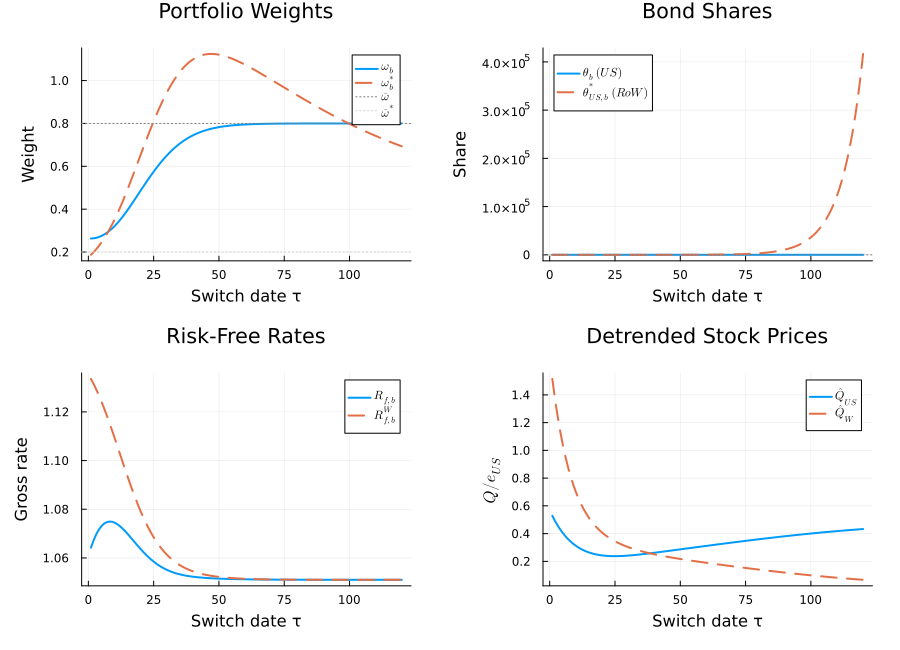

In [5]:
T = p.T_max
tt = 1:T

ω_bs   = [balanced_states[t].ω_b for t in tt]
ωs_bs  = [balanced_states[t].ω_star_b for t in tt]
θ_bs   = [balanced_states[t].θ_b for t in tt]
θUs_bs = [balanced_states[t].θ_US_star_b for t in tt]
Rf_bs  = [balanced_states[t].R_f_b for t in tt]
RfW_bs = [balanced_states[t].R_f_W_b for t in tt]
QUSh   = [balanced_states[t].Q_US_hat for t in tt]
QWh    = [balanced_states[t].Q_W_hat for t in tt]

p1 = plot(tt, ω_bs, label=L"\omega_b", lw=2, title="Portfolio Weights",
          xlabel="Switch date τ", ylabel="Weight")
plot!(p1, tt, ωs_bs, label=L"\omega^*_b", lw=2, ls=:dash)
hline!(p1, [p.ω̄], ls=:dot, lc=:gray, label=L"\bar{\omega}")
hline!(p1, [p.ω̄_star], ls=:dot, lc=:lightgray, label=L"\bar{\omega}^*")

p2 = plot(tt, θ_bs, label=L"\theta_b\ (US)", lw=2, title="Bond Shares",
          xlabel="Switch date τ", ylabel="Share")
plot!(p2, tt, θUs_bs, label=L"\theta^*_{US,b}\ (RoW)", lw=2, ls=:dash)
hline!(p2, [0.0], ls=:dot, lc=:gray, label="")

p3 = plot(tt, Rf_bs, label=L"R_{f,b}", lw=2, title="Risk-Free Rates",
          xlabel="Switch date τ", ylabel="Gross rate")
plot!(p3, tt, RfW_bs, label=L"R^W_{f,b}", lw=2, ls=:dash)

p4 = plot(tt, QUSh, label=L"\hat{Q}_{US}", lw=2, title="Detrended Stock Prices",
          xlabel="Switch date τ", ylabel=L"Q / e_{US}")
plot!(p4, tt, QWh, label=L"\hat{Q}_W", lw=2, ls=:dash)

plot(p1, p2, p3, p4, layout=(2,2), size=(900, 650), margin=5Plots.mm)

## 3. Verification

Check that at every switch date:
- Bond clearing holds: $\theta_b \hat{A} + \theta^*_{US,b} \hat{A}^* = 0$
- $\theta_b \le 0$ (US is net borrower)
- $\theta^*_{US,b} > 0$ (RoW holds US bonds)
- Stock prices are positive

In [6]:
max_bond_err = 0.0
all_signs_ok = true

for t in 1:T
    bs = balanced_states[t]
    ε = paths.e_W[t] / paths.e_US[t]
    hat_A  = p.β
    hat_As = (p.β + p.χ) / (1 + p.χ) * ε

    bond_err = abs(bs.θ_b * hat_A + bs.θ_US_star_b * hat_As)
    max_bond_err = max(max_bond_err, bond_err)

    if bs.θ_b > 1e-10 || bs.θ_US_star_b < -1e-10 || bs.Q_US_hat ≤ 0 || bs.Q_W_hat ≤ 0
        all_signs_ok = false
        @warn "Sign violation at τ=$t: θ=$(bs.θ_b), θ*_US=$(bs.θ_US_star_b), Q̂_US=$(bs.Q_US_hat), Q̂_W=$(bs.Q_W_hat)"
    end
end

@printf("Max bond clearing error: %.2e\n", max_bond_err)
println("All sign conditions (θ≤0, θ*>0, Q>0): ", all_signs_ok ? "✓" : "✗")

Max bond clearing error: 6.25e-13
All sign conditions (θ≤0, θ*>0, Q>0): ✓


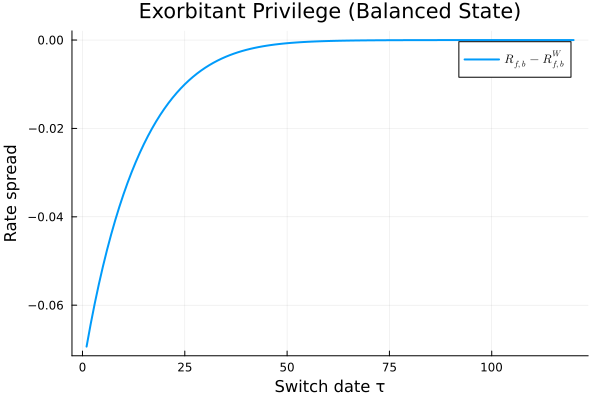

In [7]:
# ── Exorbitant privilege in balanced state ──
ep_bs = Rf_bs .- RfW_bs

plot(tt, ep_bs, lw=2, label=L"R_{f,b} - R^W_{f,b}",
     xlabel="Switch date τ", ylabel="Rate spread",
     title="Exorbitant Privilege (Balanced State)",
     legend=:topright)

## Summary

- The 5-equation balanced-state system converges reliably across all switch dates.
- $\theta_b \le 0$ (US borrows in bonds) and $\theta^*_{US,b} > 0$ (RoW holds US bonds), as required by the convenience yield.
- As $\tau$ increases, the US dividend-to-endowment ratio at the switch falls, shifting the balanced-state allocation.
- The exorbitant privilege ($R_f - R_f^W > 0$) is positive, reflecting the RoW's convenience yield demand.

**Next**: Notebook 03 uses these balanced-state solutions to solve the u-path equilibrium via backward induction.